# 00 - Exploratory Data Analysis

This notebook documents the EDA that motivated the macro-regime factor rotation models.

It does not redistribute the competition dataset. To run it locally, place `train.csv`, `test.csv`, and `sample_submission.csv` in `E:/wright_quant/data` or update `DATA_DIR`.

### Cell 1 - Import Libraries and Configure Paths

This cell imports the analysis libraries and defines paths for local data and existing EDA figures.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

try:
    from IPython.display import Image, display
except Exception:
    Image = None
    display = print

PROJECT_ROOT = Path.cwd()
if not ((PROJECT_ROOT / "outputs").exists() or (PROJECT_ROOT.parent / "outputs").exists()):
    PROJECT_ROOT = Path(r"C:\Users\sankalp.DESKTOP-1RPOQ63\Documents\Codex\2026-06-12\files-mentioned-by-the-user-pasted")
elif not (PROJECT_ROOT / "outputs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = Path(r"E:\wright_quant\data")
FIG_DIR = PROJECT_ROOT / "outputs"
RANK_COLS = ["rank_momentum", "rank_quality", "rank_value"]
FWD_COLS = ["fwd_momentum", "fwd_quality", "fwd_value"]

### Cell 2 - Load Training and Test Data

This cell loads the monthly macro panel and target ranks. The test data contains macro features only.

In [2]:
train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)
test = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)

feature_cols = [c for c in train.columns if c not in ["date", *RANK_COLS, *FWD_COLS]]
print("Train rows:", len(train), "| Test rows:", len(test), "| Macro features:", len(feature_cols))
print("Train period:", train["date"].min().date(), "to", train["date"].max().date())
print("Test period:", test["date"].min().date(), "to", test["date"].max().date())
train[["date", *RANK_COLS]].head()

ExecutionError: FileNotFoundError: [Errno 2] No such file or directory: 'E:\\wright_quant\\data\\train.csv'

### Cell 3 - Rank Distribution and Base Rates

This cell identifies which factor won most often in the training sample.

In [3]:
winner_map = {
    "rank_momentum": "Momentum",
    "rank_quality": "Quality",
    "rank_value": "Value",
}
train["winner"] = train[RANK_COLS].idxmin(axis=1).map(winner_map)
rank_distribution = train["winner"].value_counts(normalize=True).rename("win_rate").to_frame()
rank_distribution["count"] = train["winner"].value_counts()
rank_distribution

ExecutionError: NameError: name 'train' is not defined

### Cell 4 - Display EDA Figure: Rank Distribution

This cell displays the rank-count and winner-frequency chart generated by the EDA script.

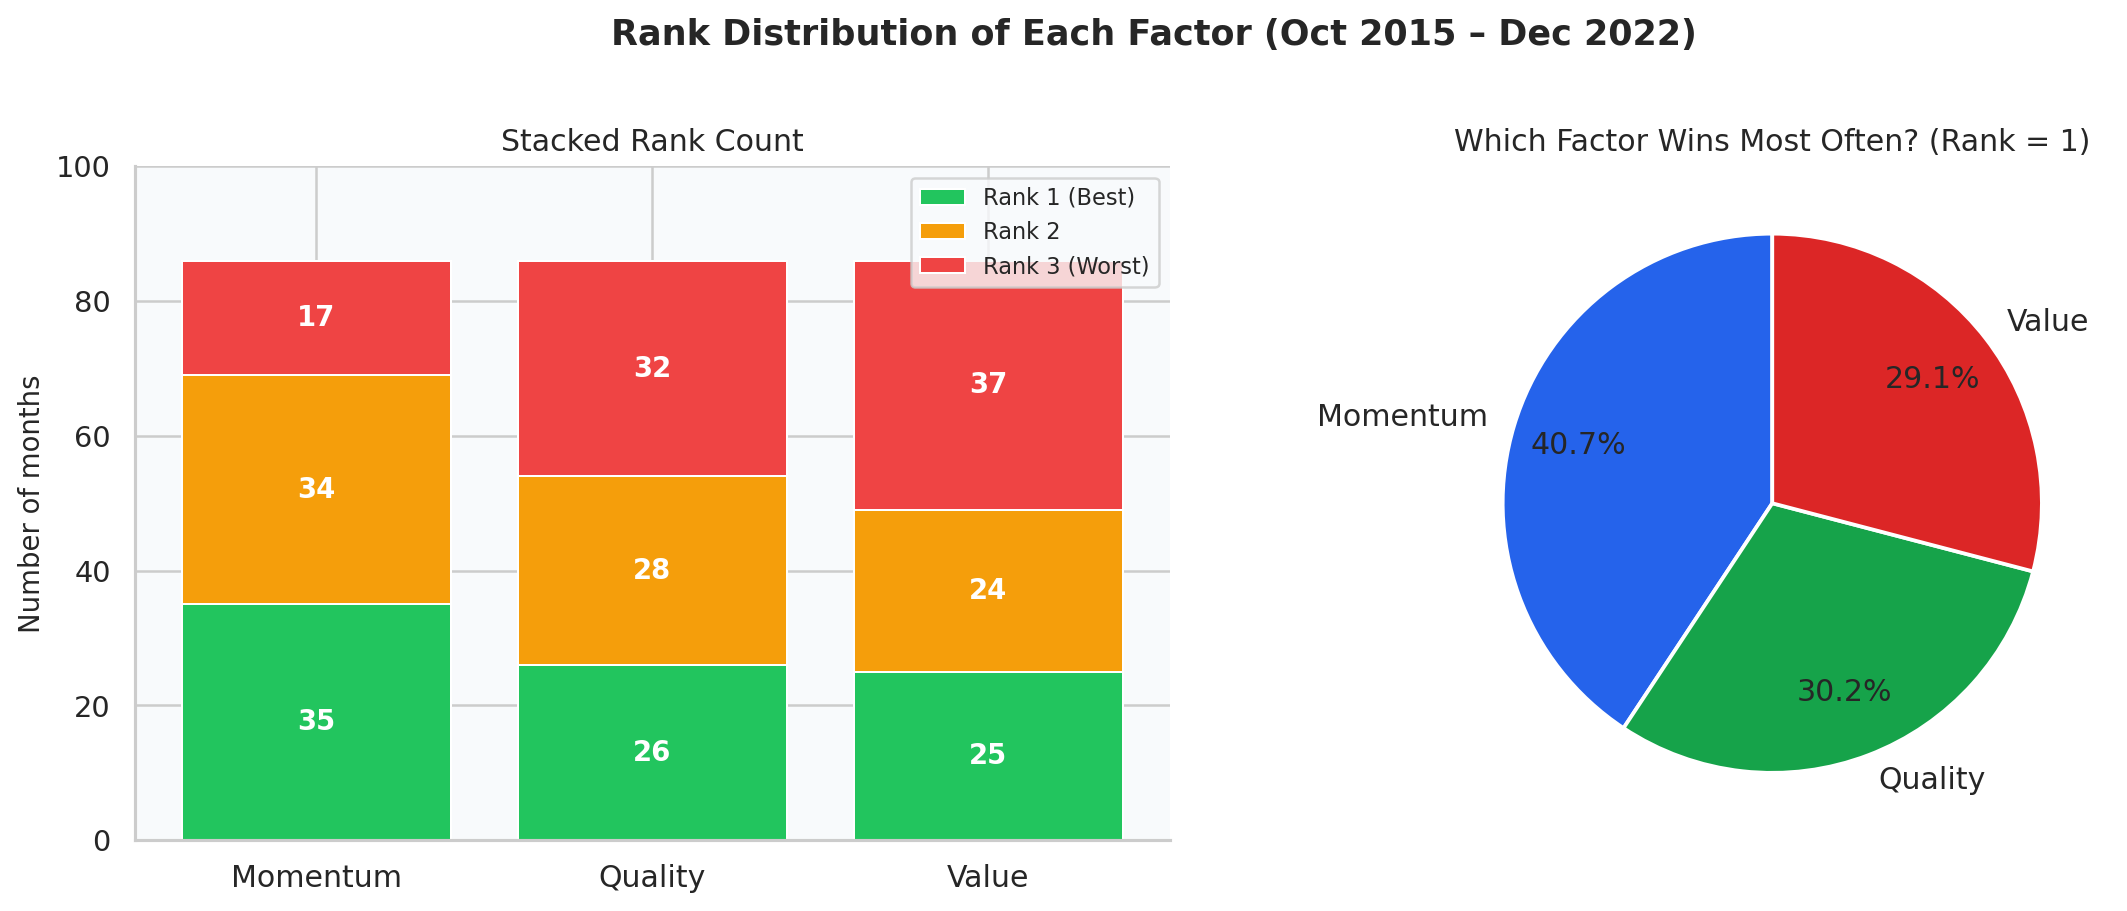

In [4]:
img = FIG_DIR / "01_rank_distribution.png"
if Image and img.exists():
    display(Image(filename=str(img)))
else:
    print(img)

### Cell 5 - Factor Leadership Over Time

This cell displays the monthly winner map and rolling forward returns.

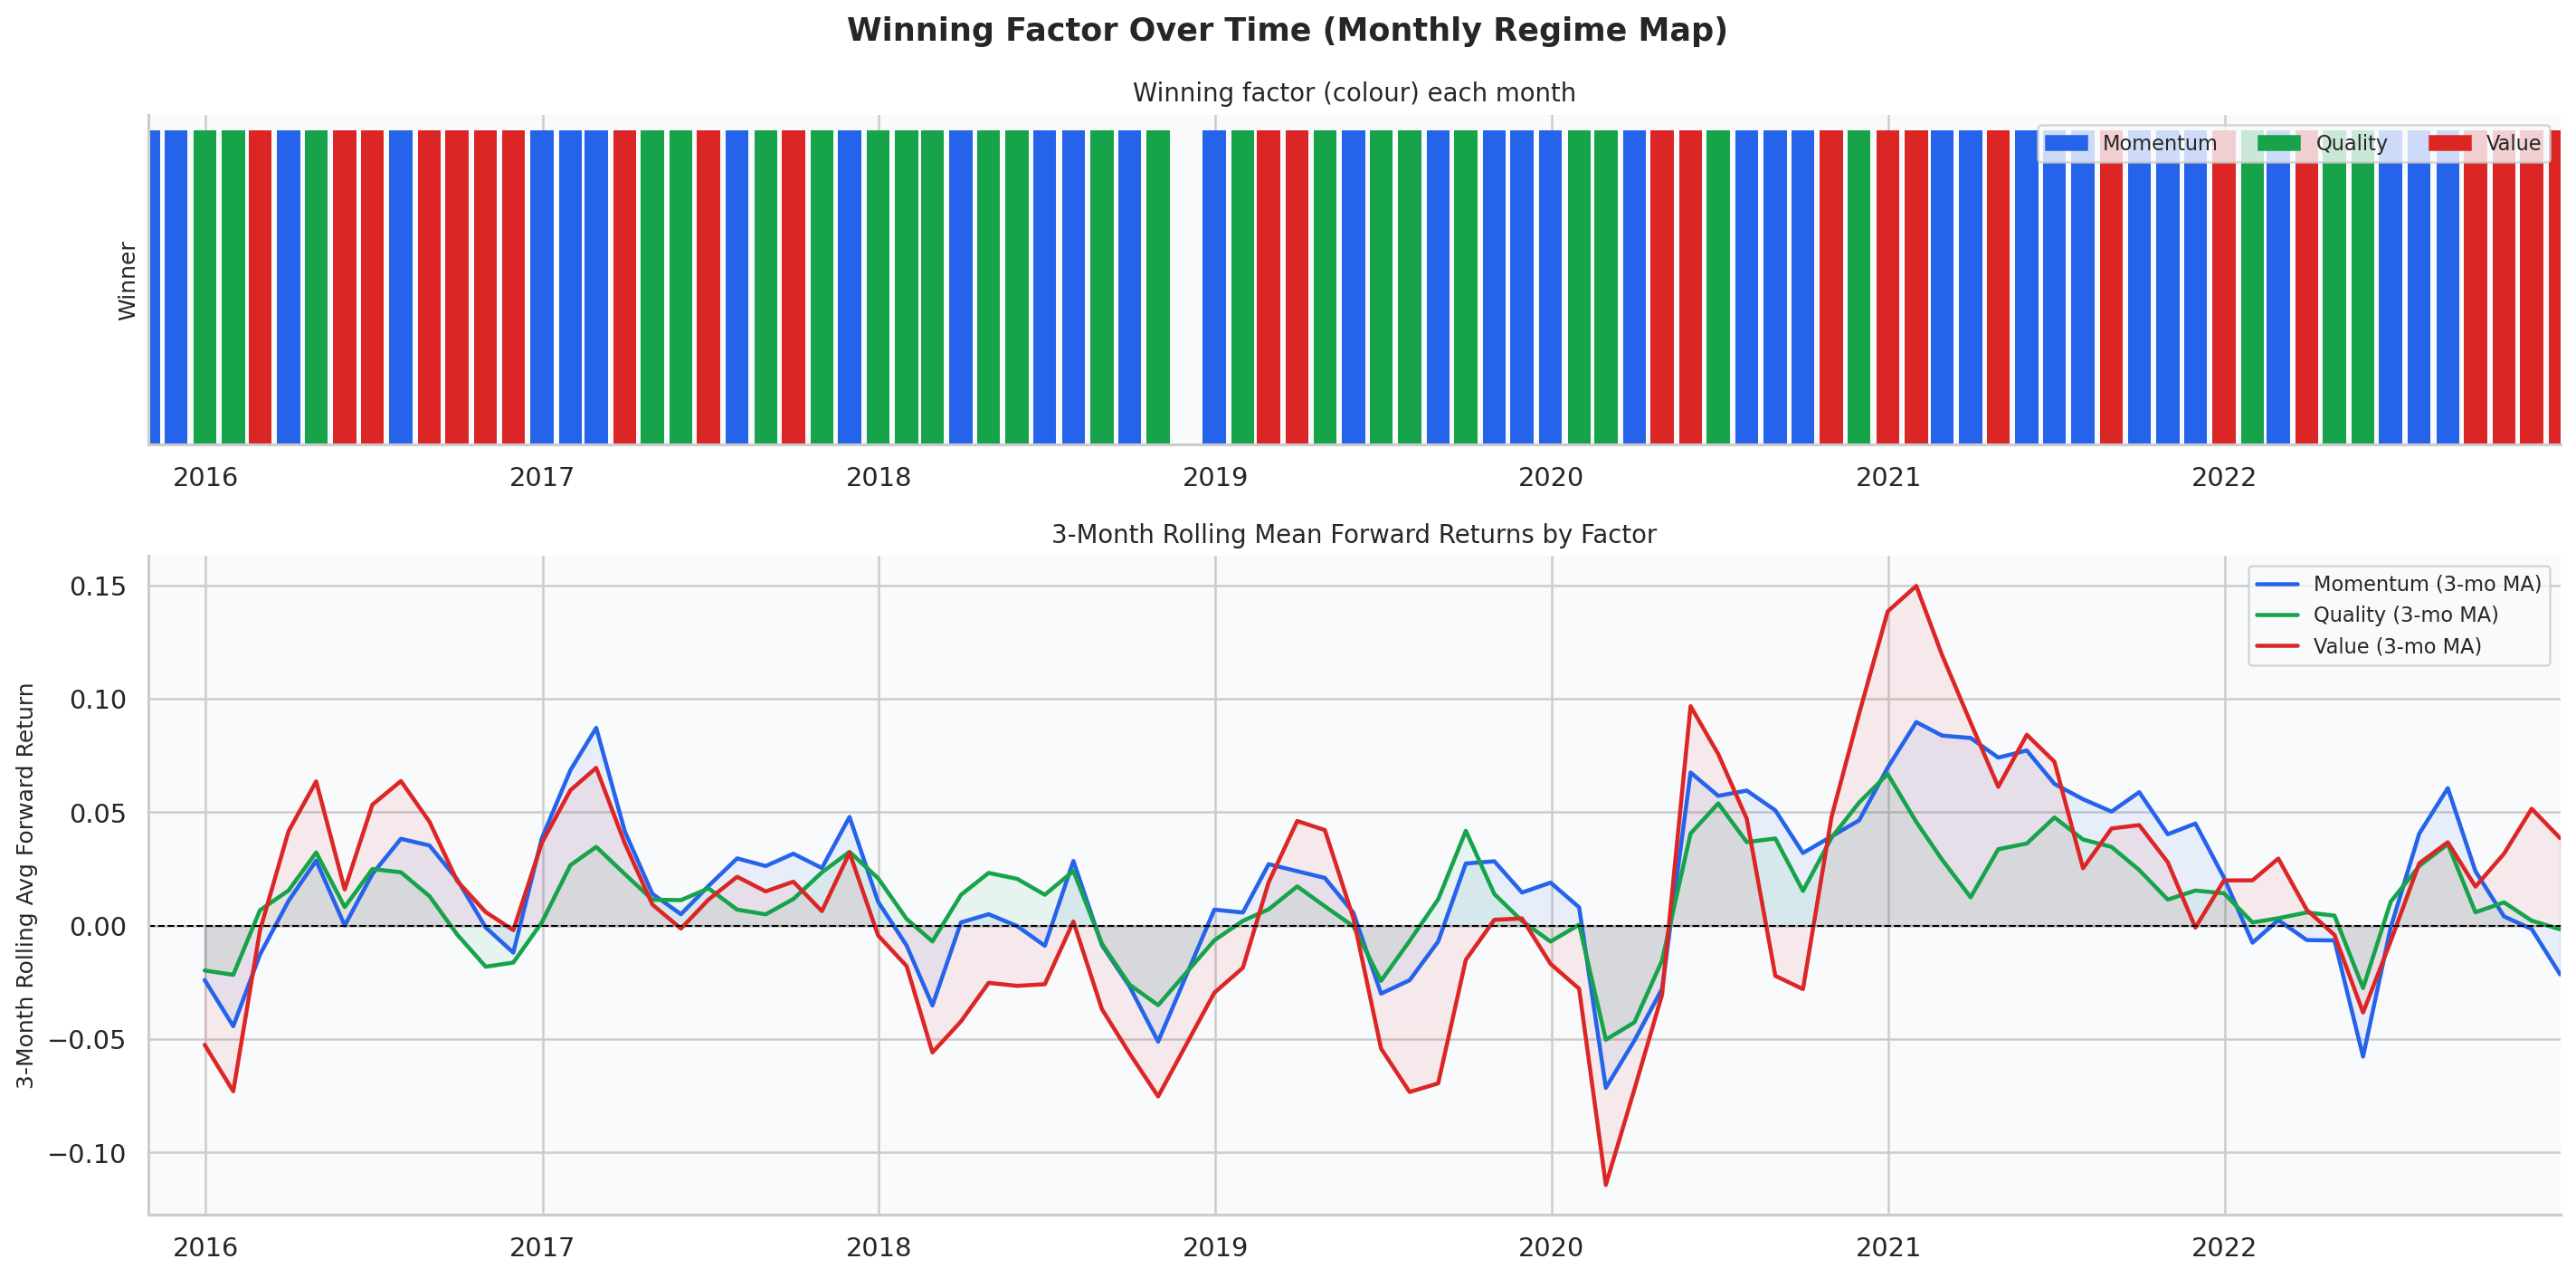

In [5]:
img = FIG_DIR / "02_winner_timeseries.png"
if Image and img.exists():
    display(Image(filename=str(img)))
else:
    print(img)

### Cell 6 - Rank Autocorrelation and Transition Intuition

This cell displays whether factor leadership persists over monthly horizons.

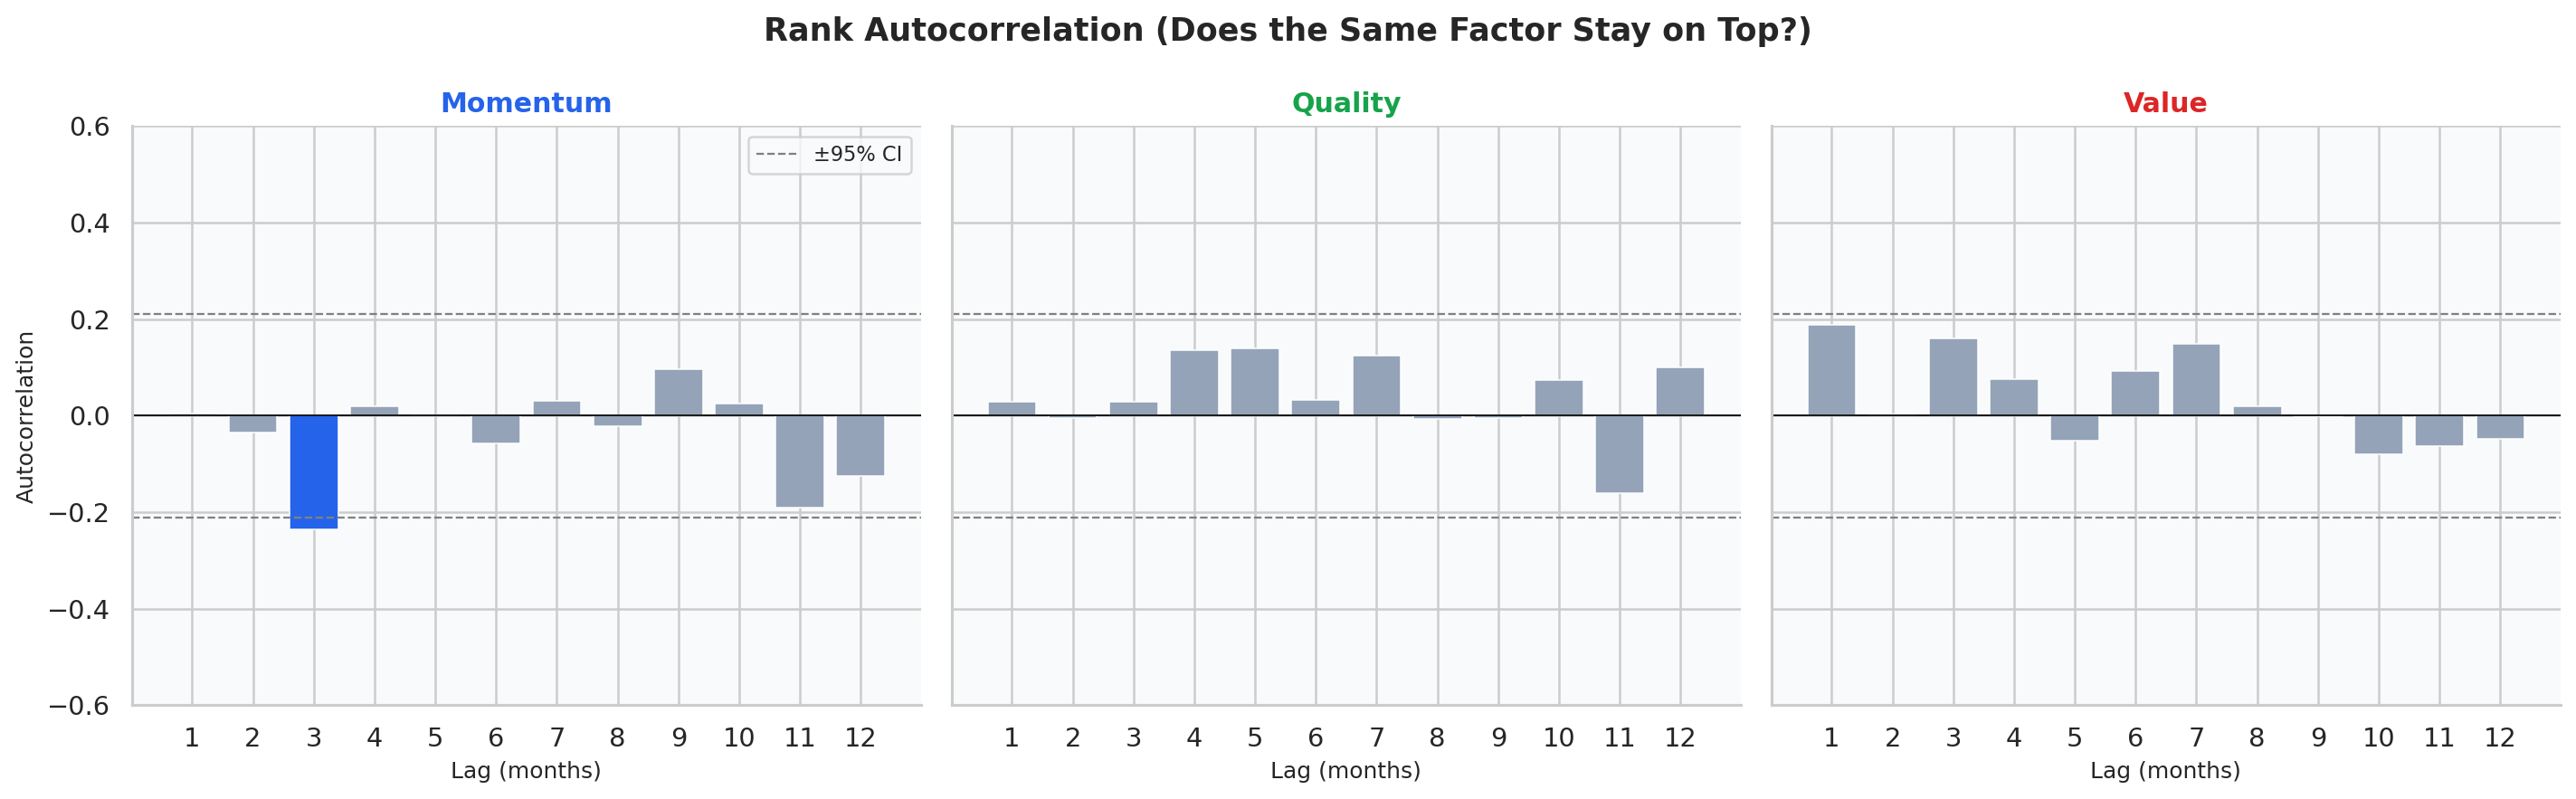

In [6]:
img = FIG_DIR / "03_rank_autocorrelation.png"
if Image and img.exists():
    display(Image(filename=str(img)))
else:
    print(img)

### Cell 7 - Macro Feature Correlations

This cell computes simple Spearman correlations between macro features and next-month factor ranks.

In [7]:
corr = pd.DataFrame({
    factor: train[feature_cols].corrwith(train[col], method="spearman")
    for factor, col in zip(["Momentum", "Quality", "Value"], RANK_COLS)
})
summary = corr.assign(max_abs=corr.abs().max(axis=1)).sort_values("max_abs", ascending=False).drop(columns="max_abs")
summary.head(15)

ExecutionError: NameError: name 'train' is not defined

### Cell 8 - Display EDA Figure: Correlation Heatmap

This cell displays the full macro-feature correlation heatmap.

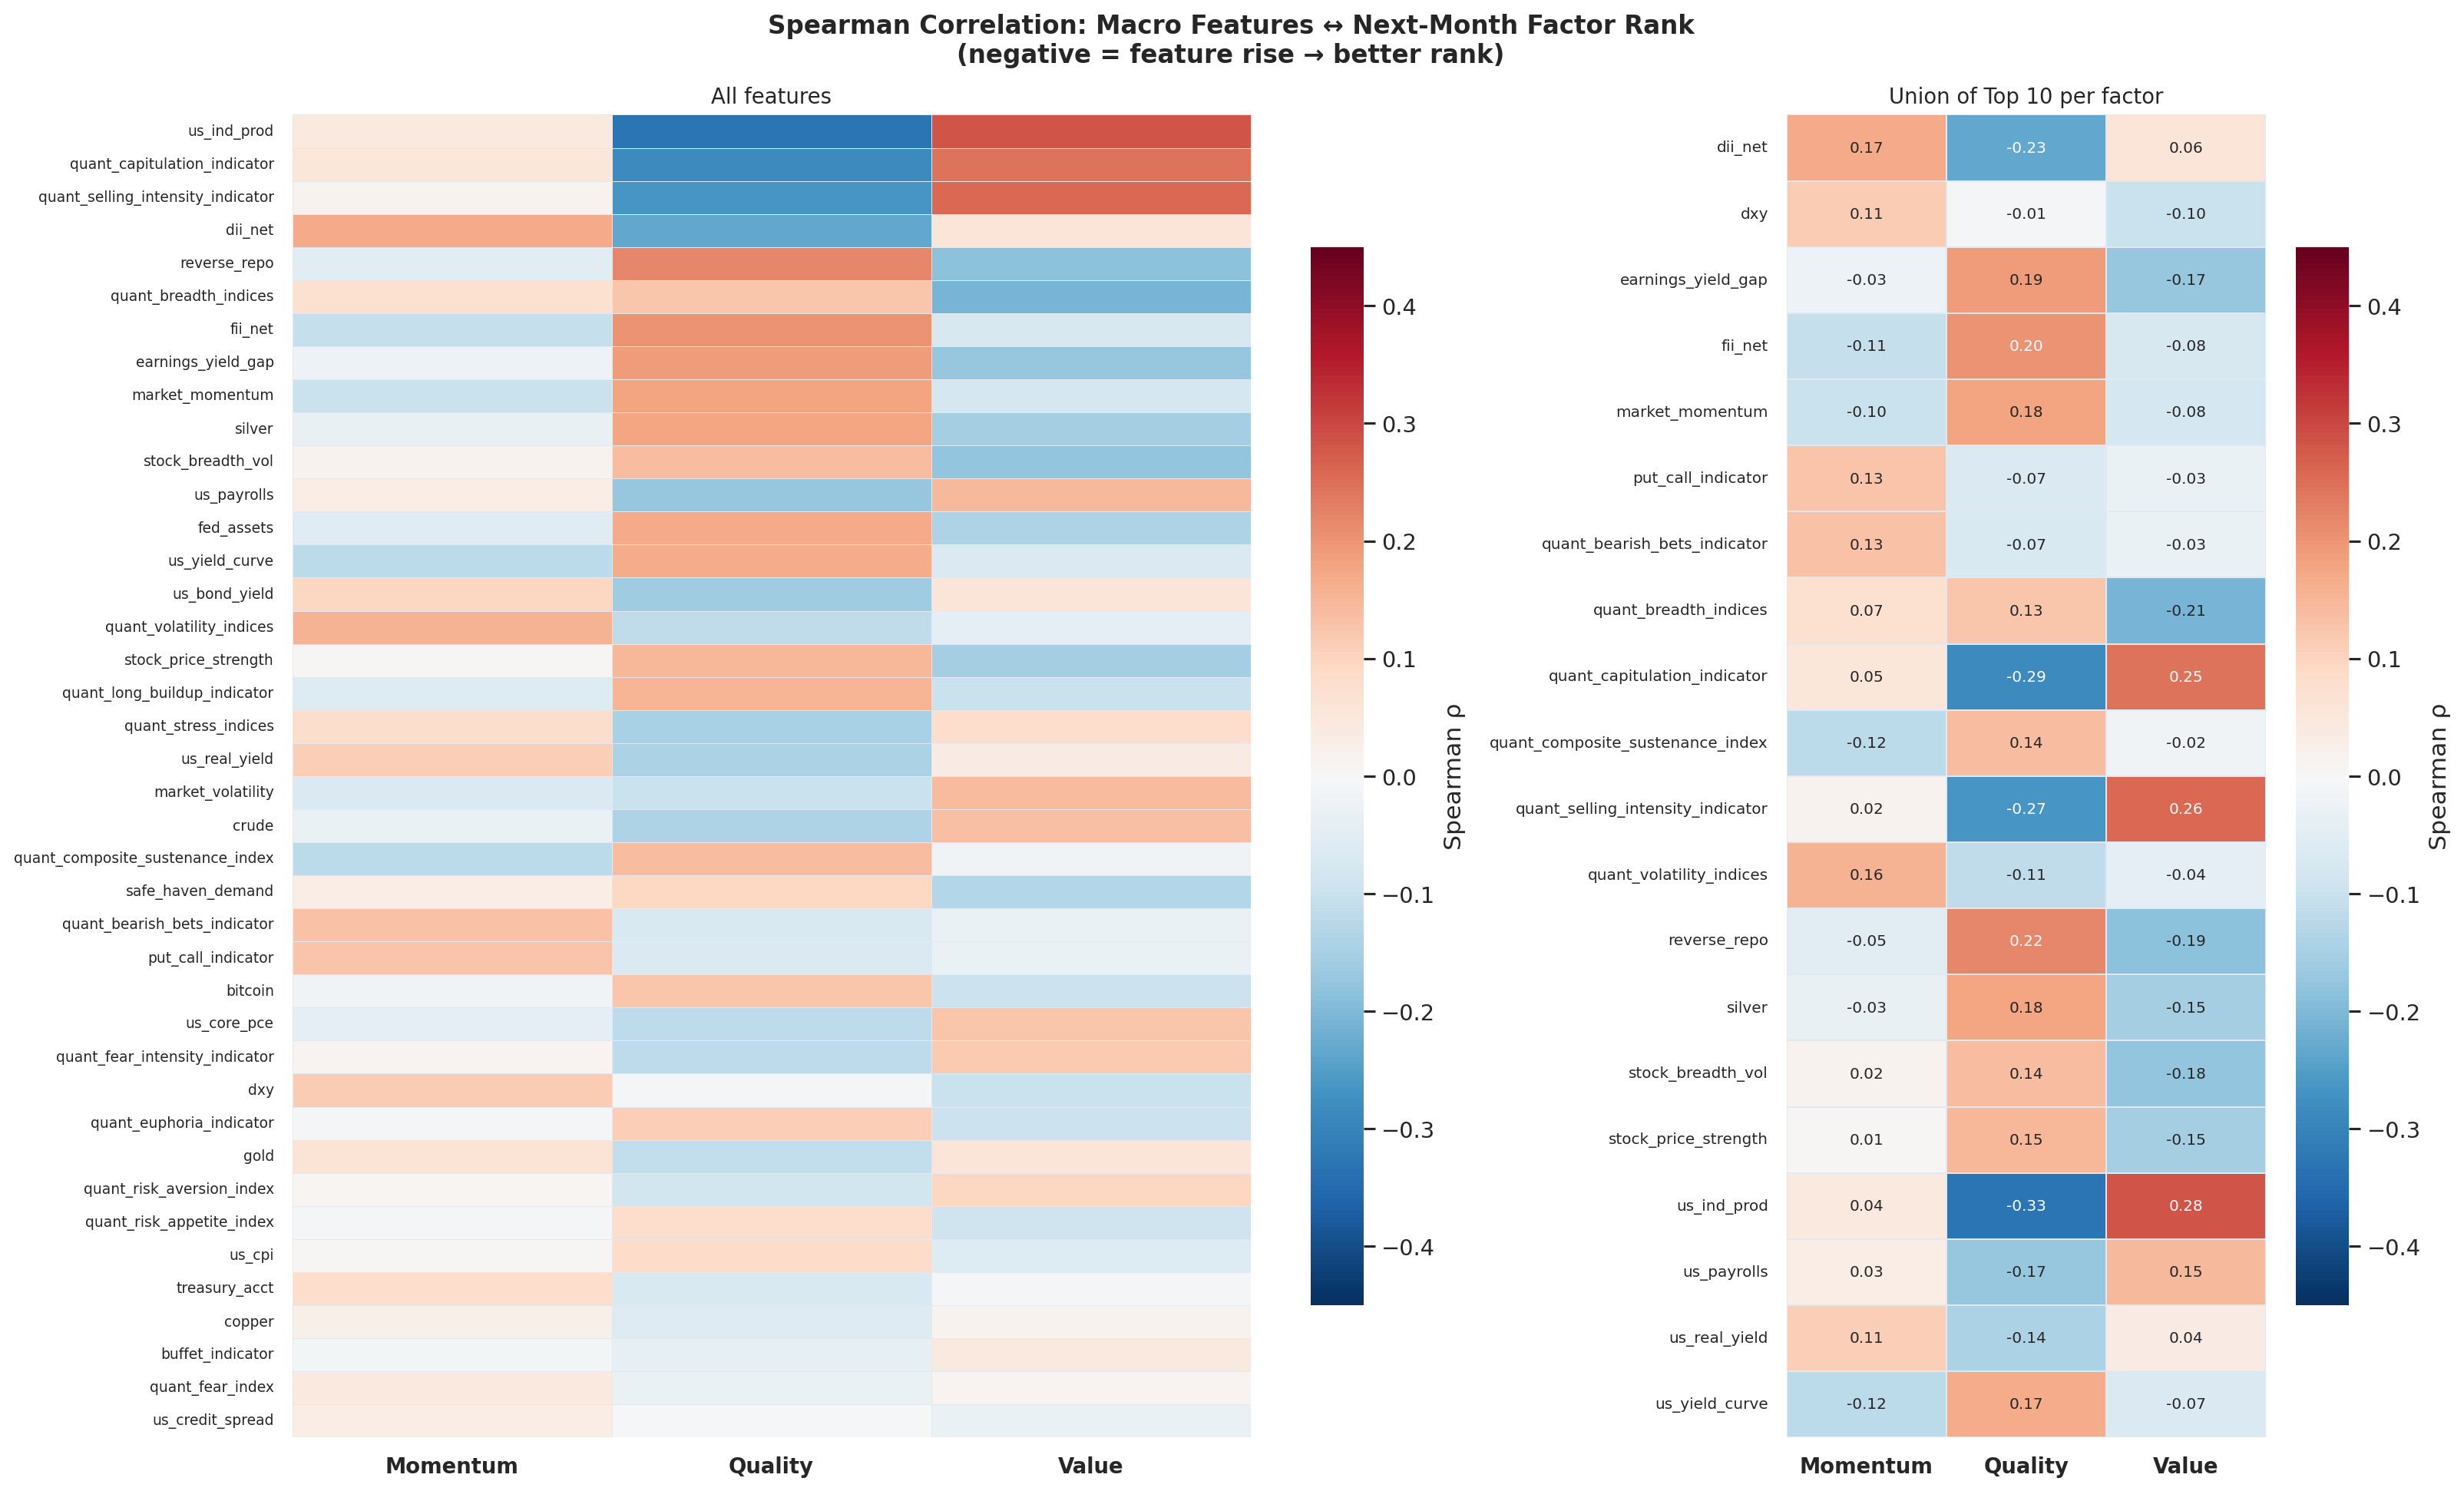

In [8]:
img = FIG_DIR / "04_correlation_heatmap.png"
if Image and img.exists():
    display(Image(filename=str(img)))
else:
    print(img)

### Cell 9 - Regime and Transition Visuals

These charts motivated the scorecard, regime-similarity, and transition-prior models.

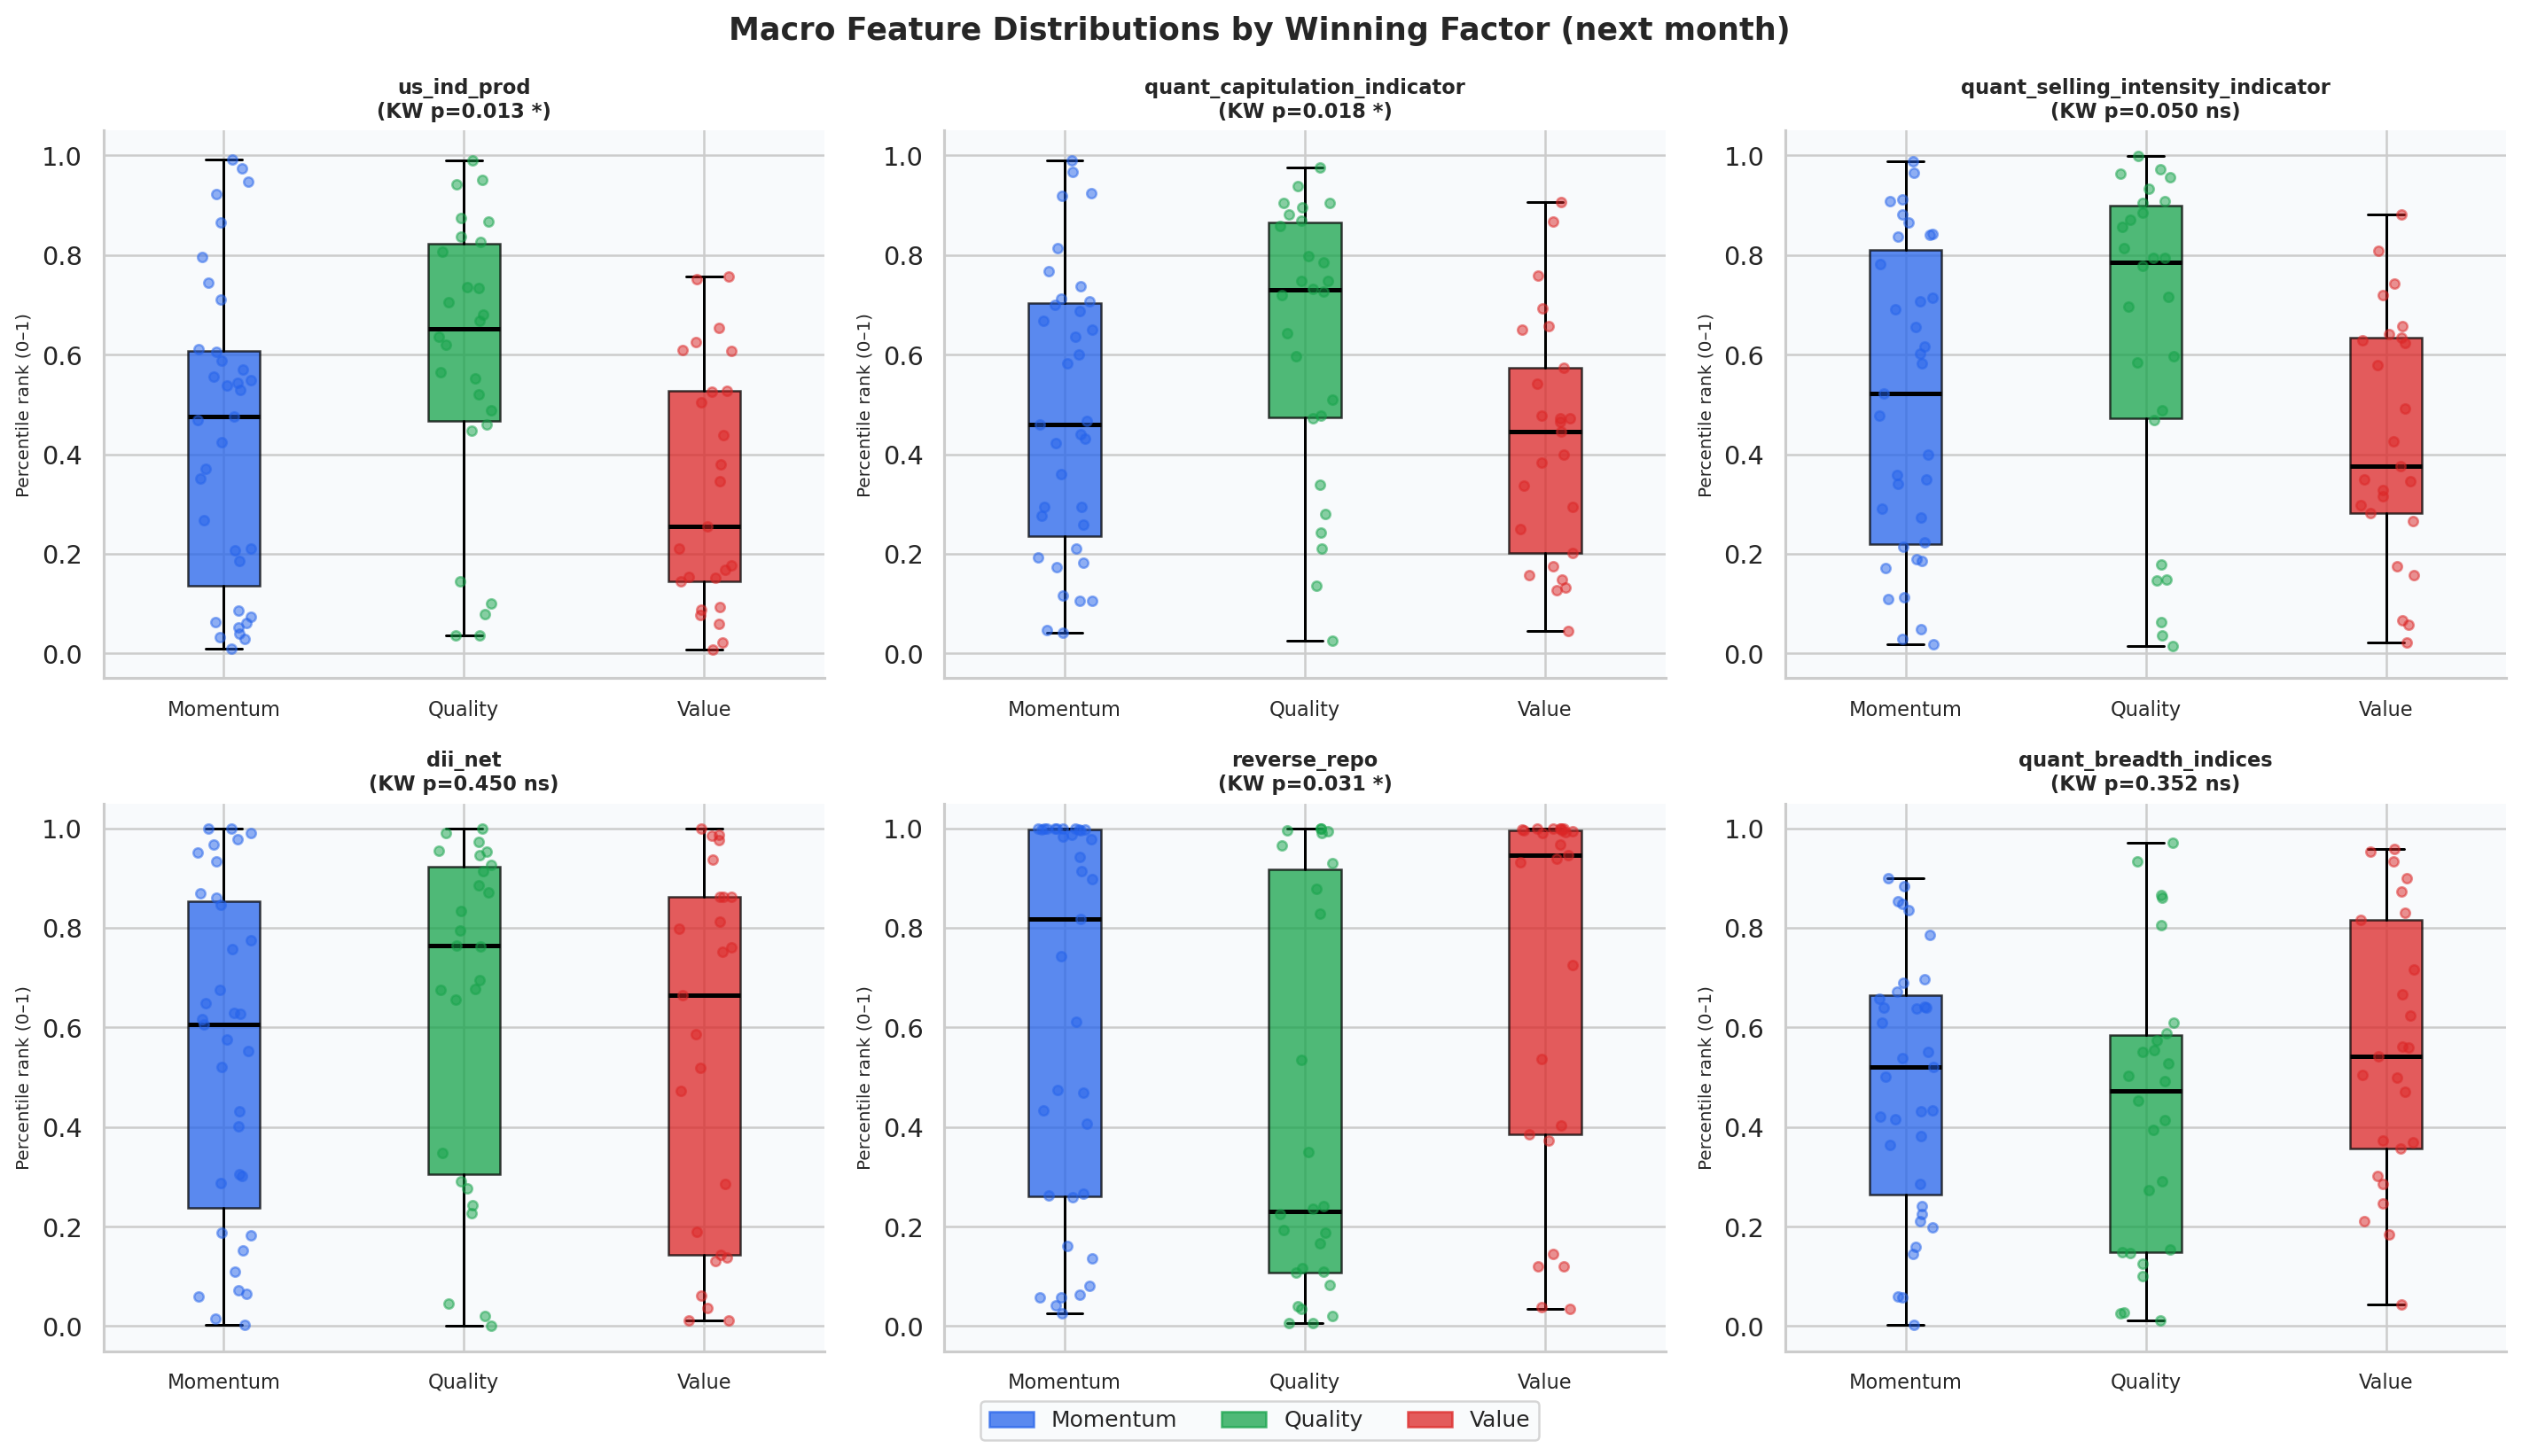

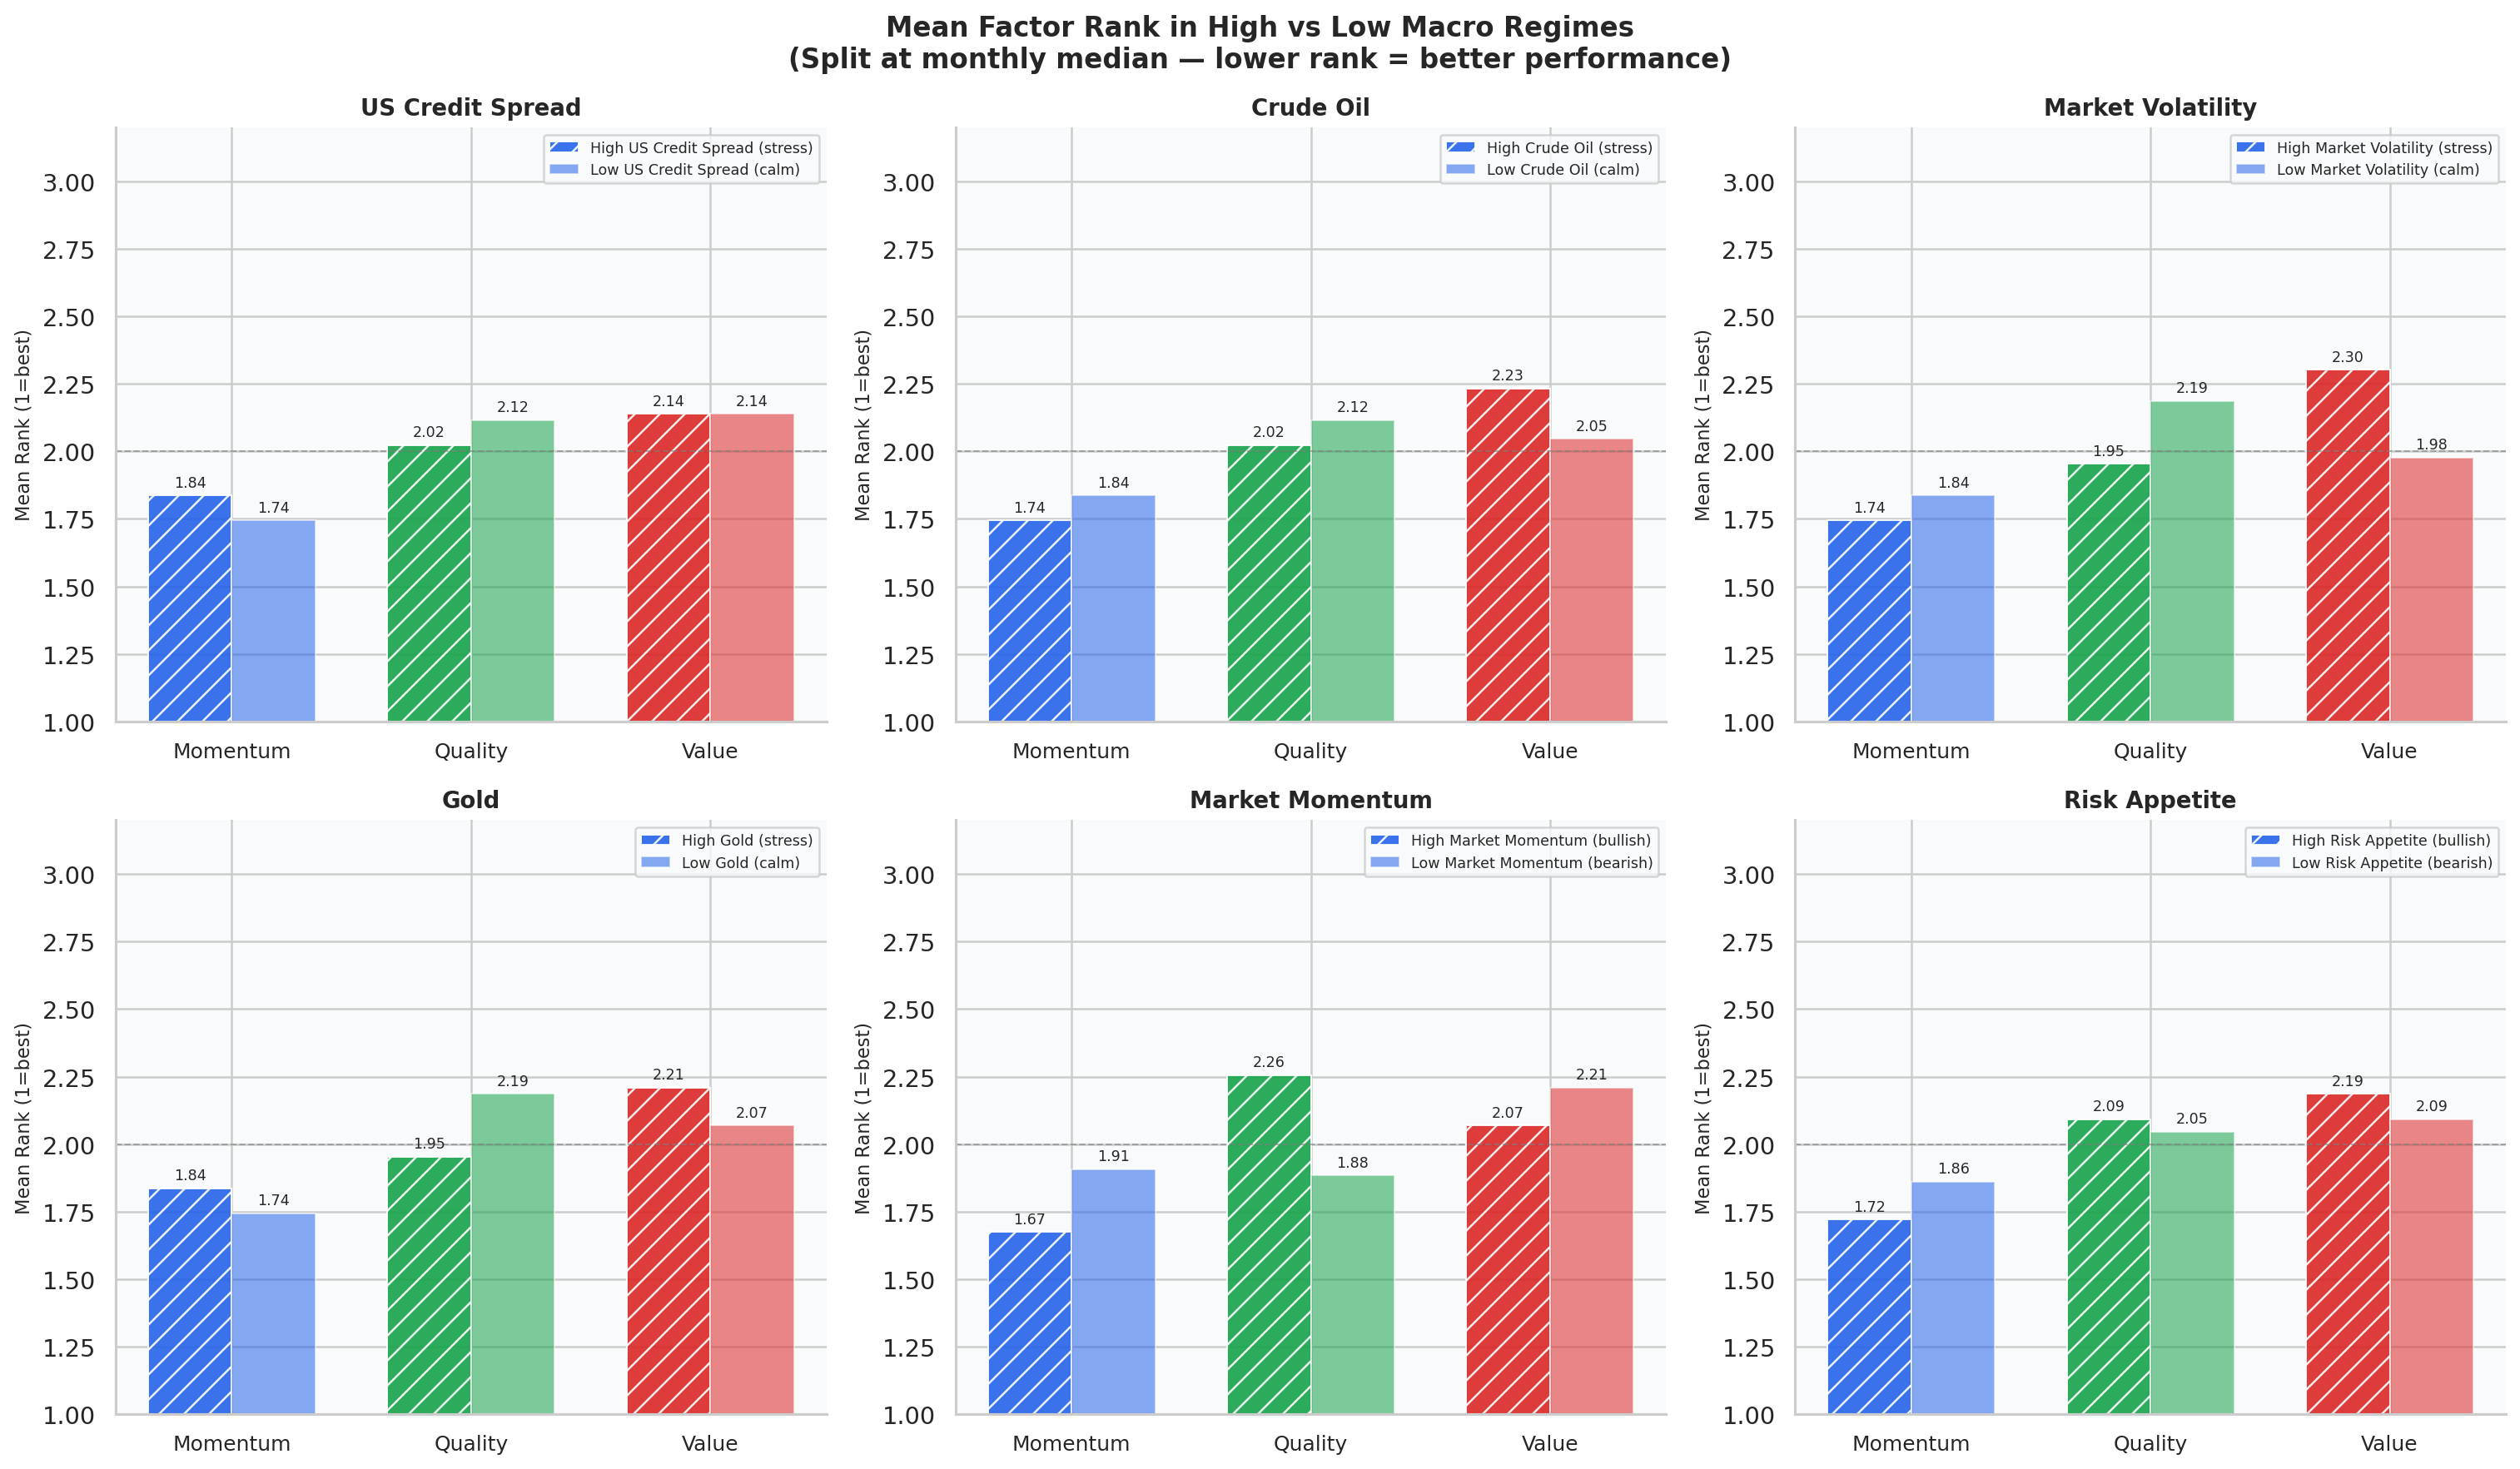

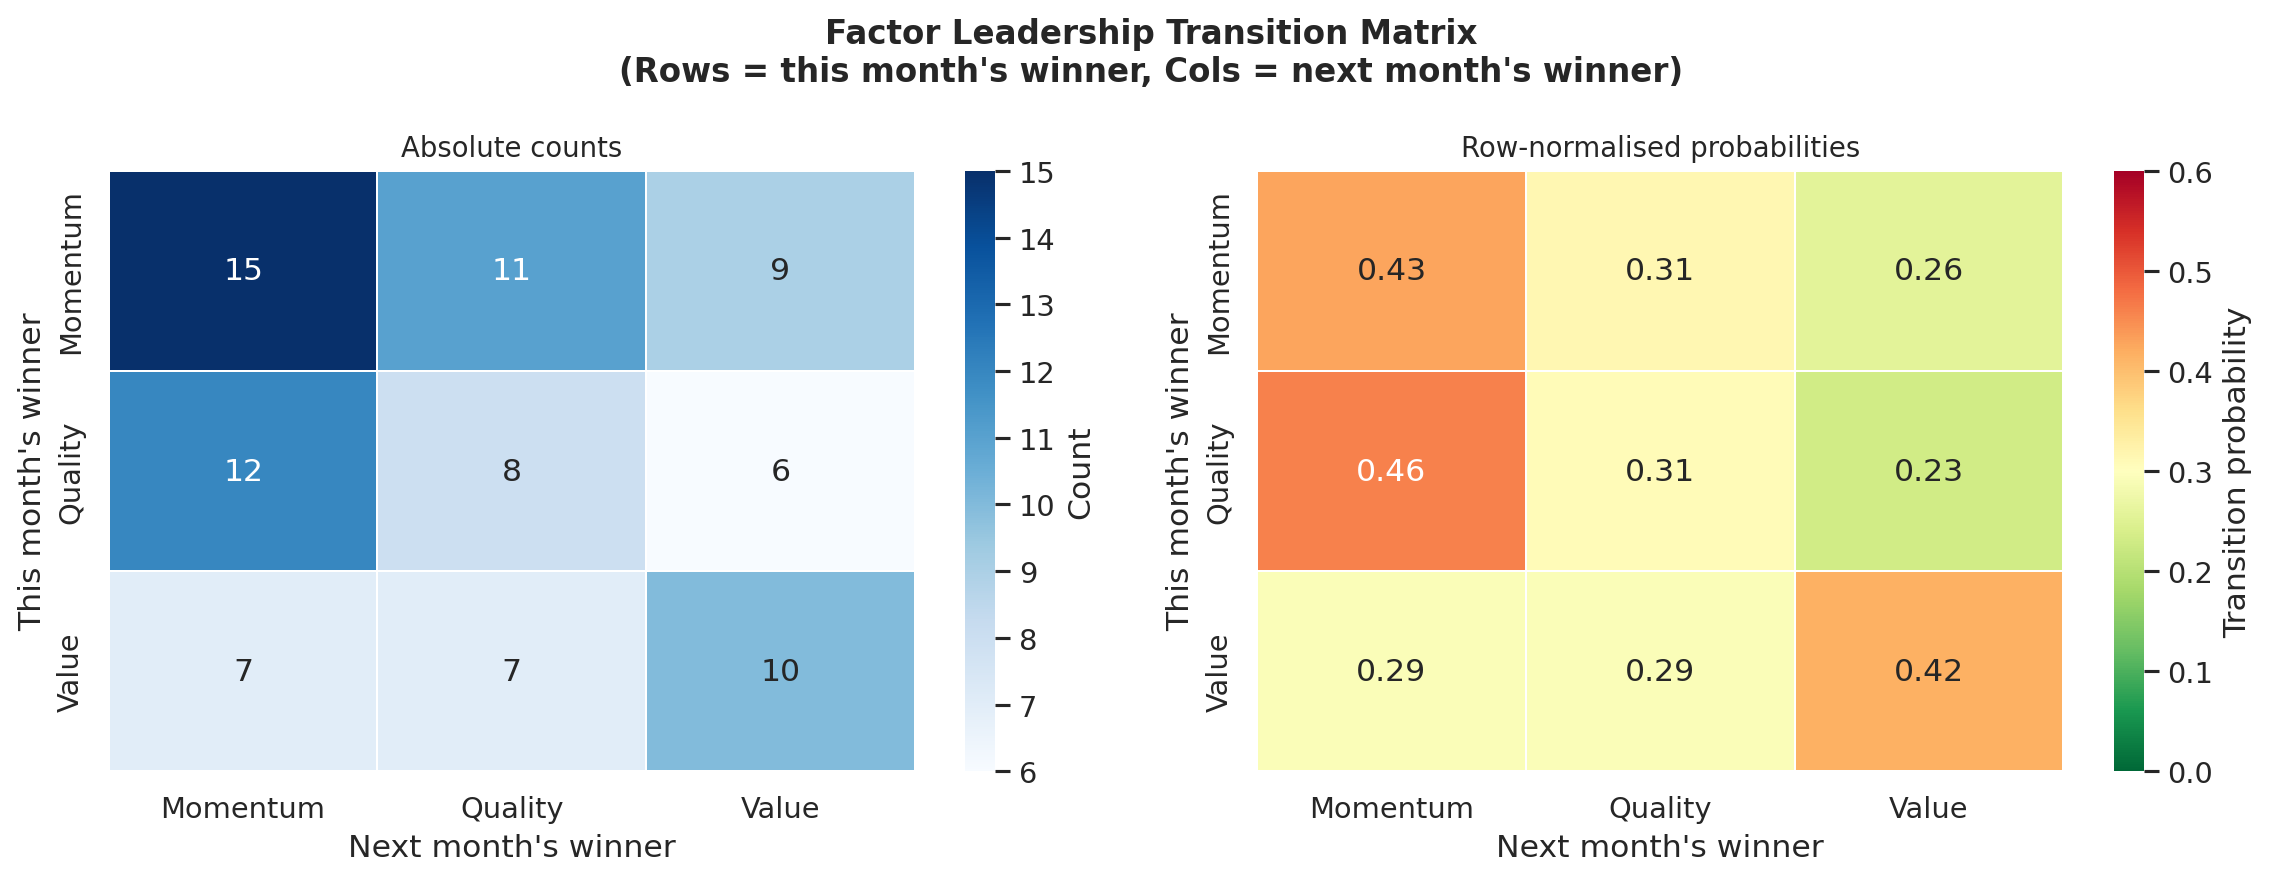

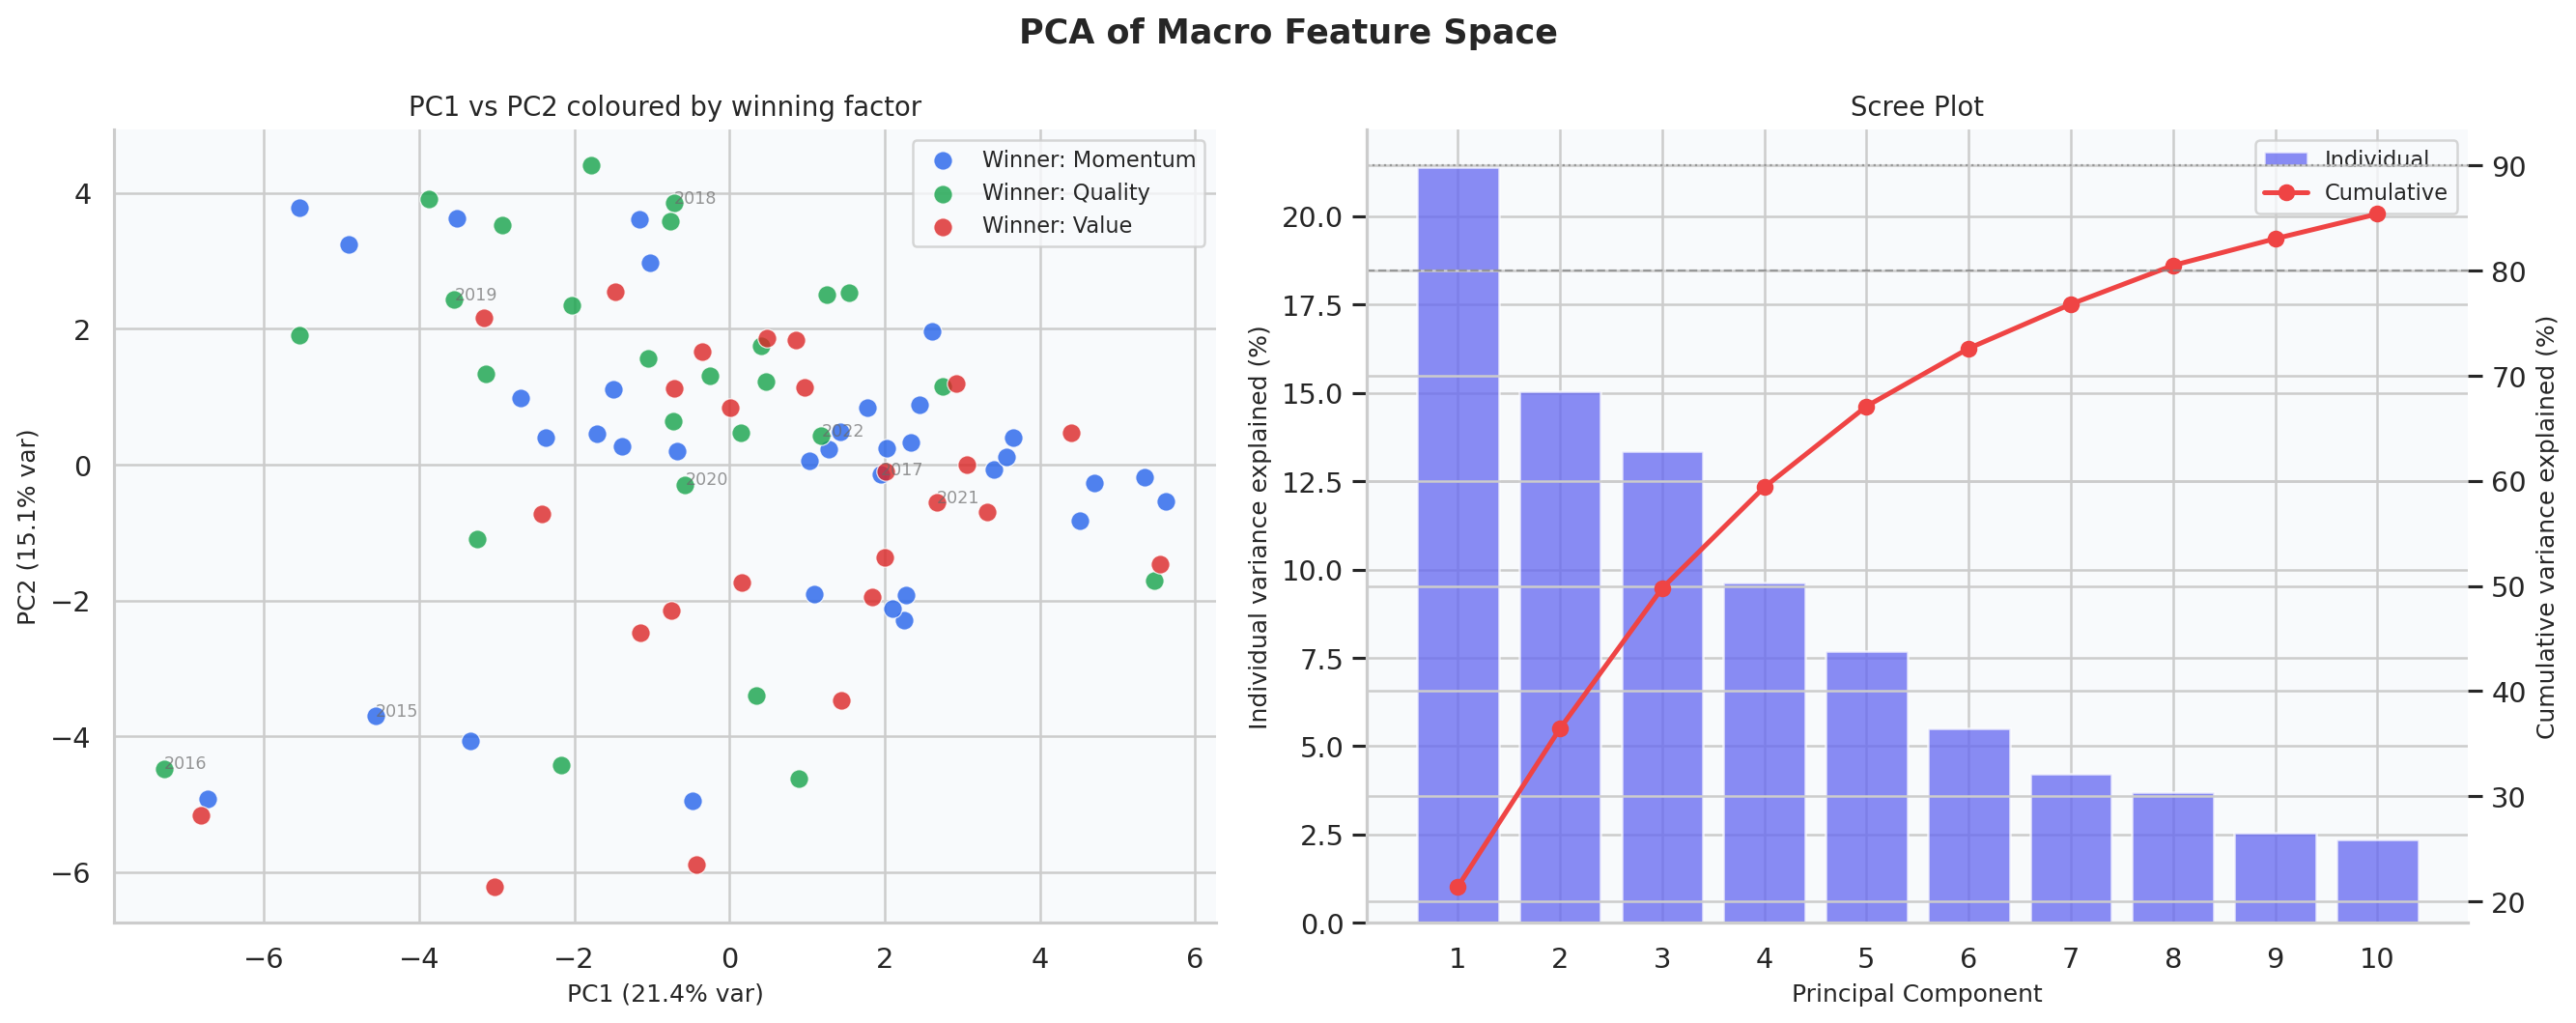

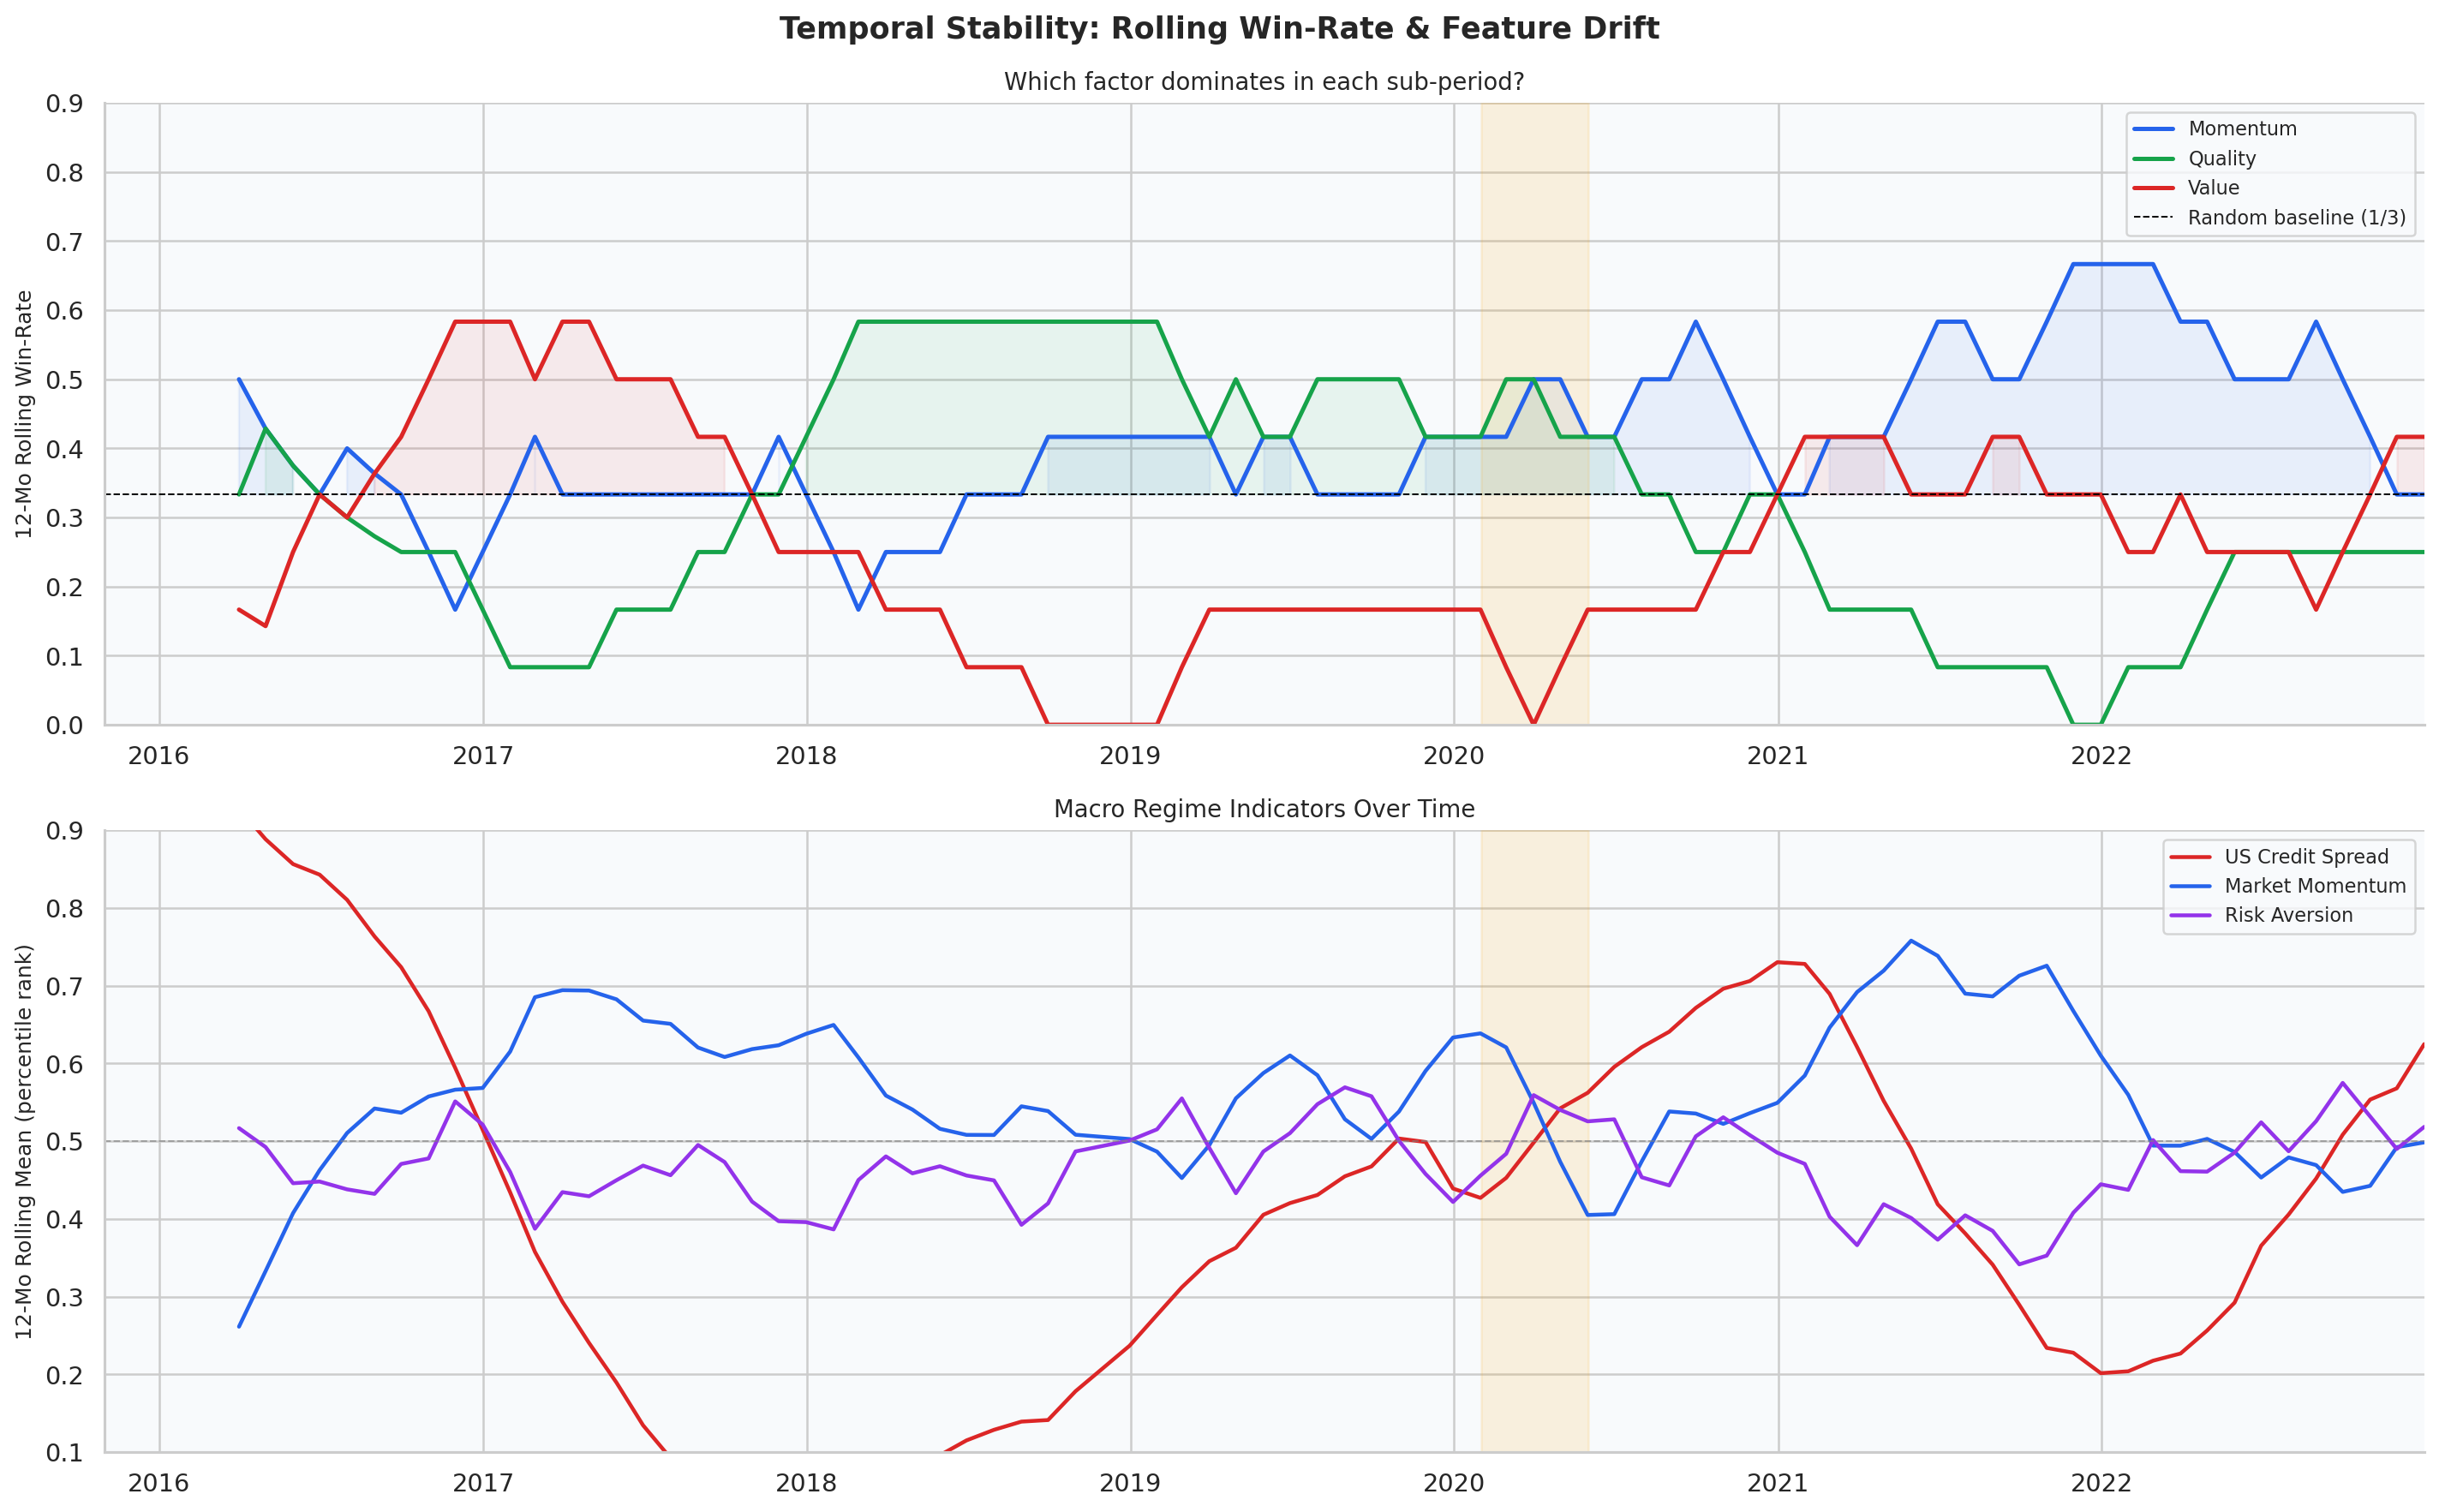

In [9]:
for name in ["05_feature_boxplots.png", "06_regime_analysis.png", "07_transition_matrix.png", "08_pca.png", "09_temporal_stability.png"]:
    img = FIG_DIR / name
    if Image and img.exists():
        display(Image(filename=str(img)))
    else:
        print(img)

### Cell 10 - EDA Takeaways

The EDA suggested three useful signals:

1. Momentum has the strongest base-rate advantage.
2. Quality tends to improve in stress/capitulation regimes.
3. Value is more cyclical and needs recovery/reflation support.

These observations became the foundation for the scorecard and research-hybrid notebooks.